# Calculate the dynamic sea level contribution from Helene's computed scalars

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd

sns.set_context("paper")
sns.set_style("whitegrid")

computed_name = 'ComputedScalarsHelene'

In [2]:
path = '/mnt/ronja/nci/ismip6_hackathon/'

pth_calc_output = '/mnt/ronja/nci/ismip6_hackathon/ComputedScalars/'

In [4]:
df = pd.read_csv('Metadata.txt') 

In [5]:
def calc_dynamic_sl_anom(d1,d1c,d2, d2c,dt):
    # d1 = data_ivaf, d1c=data_ivaf_ctrl
    # d2 = data_smbgr, d2c = data_smbgr_ctrl
    
    dynamic_sl_anom = np.zeros_like(d1)
    for t in range(1,len(d1)):
        dynamic_sl_anom[t] = d1[t] - d1c[t] - np.nansum(d2[:t] - d2c[:t])*dt  
    
    return dynamic_sl_anom

In [ ]:
expnames = ['expAE02','expAE03', 'expAE04', 'expAE05'] 

yearlen = 360*24*60*60 # FIXME: is this the same for all models? if not, does it matter?


# this is the name of the variable to be generated
variable_name = 'dslc_anom'

regions =['region_1','region_2','region_3']
sectors =[]
for i in range(18):
    sectors.append('sector_'+str(i+1))

    
    
# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    
    file_exp = os.listdir(path+f"{computed_name}/{expname}/ivaf")
    file_exp = [file for file in file_exp if len(file) >= 3]
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]
    
    # iterate over all file names 
    for ifile in range(len(file_exp)):
        
        #print(ifile)
        
        filename = path+f"{computed_name}/{expname}/ivaf/{file_exp[ifile]}"
        d_ivaf = xr.open_dataset(filename,decode_times=False )
          
        filename_end =file_exp[ifile].split("computed_ivaf")[-1]
        
        d_ivaf_ctrl = xr.open_dataset(filename.replace(expname, 'ctrlAE'),decode_times=False)
        
        filename2 = path+f"{computed_name}/{expname}/smbgr/computed_smbgr"+filename_end
        d_smbgr = xr.open_dataset(filename2,decode_times=False ) 
        d_smbgr_ctrl = xr.open_dataset(filename2.replace(expname, 'ctrlAE'),decode_times=False ) 
        
        # create a new xarray
        d_new =d_ivaf.copy()
        d_new.attrs ={}
        #rename
        d_new =d_new.rename({'ivaf':variable_name })
        for region in regions:
            varname_old = 'ivaf'+'_'+region
            varname_new = variable_name+'_'+region    
            d_new =d_new.rename({varname_old:varname_new })
        for sector in sectors:
            varname_old = 'ivaf'+'_'+sector
            varname_new = variable_name+'_'+sector 
            d_new =d_new.rename({varname_old:varname_new })
   
        # Loop through each variable in the dataset and add values
        for var_name in d_new.variables:
            if (var_name != 'time') and (var_name != 'rhoi') and (var_name != 'rhow'):
                
                var_name_ivaf = var_name.replace('dslc_anom', 'ivaf')
                data_ivaf = d_ivaf[var_name_ivaf].values # Gt
                data_ivaf_ctrl = d_ivaf_ctrl[var_name_ivaf].values # Gt
                
                var_name_smbgr = var_name.replace('dslc_anom', 'smbgr')
                data_smbgr = d_smbgr[var_name_smbgr].values/1e12*yearlen  # kg/s to Gt/a
                data_smbgr_ctrl = d_smbgr_ctrl[var_name_smbgr].values/1e12*yearlen  # kg/s to Gt/a

                dt = 1 # FIXME we assume a yearly time step
                dynamic_sl_anom = calc_dynamic_sl_anom(data_ivaf,data_ivaf_ctrl,data_smbgr, data_smbgr_ctrl,dt)
                d_new[var_name].values =  np.squeeze(dynamic_sl_anom) 
        
        
        # save dataset 
        save_name = filename.split('/')[-1].split('/')[-1].replace('ivaf', variable_name)
        path_save = f"{pth_calc_output}{expname}/{variable_name}"
        
        if not os.path.exists(f"{pth_calc_output}{expname}" ):
            os.mkdir(f"{pth_calc_output}{expname}" )
        if not os.path.exists(f"{pth_calc_output}{expname}/{variable_name}" ):
            os.mkdir(f"{pth_calc_output}{expname}/{variable_name}" )
            
        
        d_new.to_netcdf(path_save+'/'+save_name)    

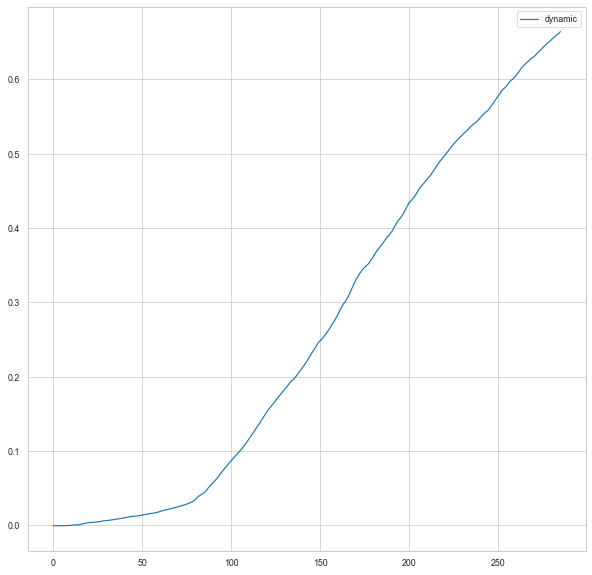

In [94]:
# gt to sle

rhow= 1028
oceanarea = 361e6*1000**2 # m2 
plt.figure(figsize=(10,10))

ind = -1

plt.plot(-1*d_calc['dslc']*1e12/rhow/oceanarea , label='dynamic')
#plt.plot(-1*sl[ind]*1e12/rhow/oceanarea , label='full')
#plt.plot((data-datac)*-1*1e12/rhow/oceanarea, label='full')

plt.legend()